In [3]:
import sys
sys.path.insert(0, '..')

In [4]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


In [5]:
wf_wid = 512
wid = 80
oversample = 4

nwavels = 3
npoly=1

n_modes = 35
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(wf_wid, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

# vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
# assert vects.shape == (nwavels, npoly)
# spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

# extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    exposure_from_file(ddir + 'n8jv51u6q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F187N"), crop=wid, extra_bad=None, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


159.962 5.4
Version 4.1.1
-100.43


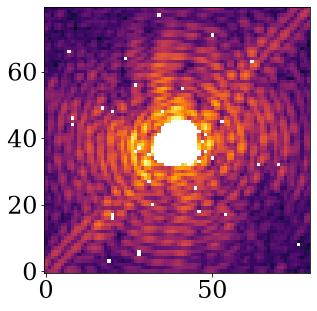

In [6]:
plt.imshow(exposures_single[0].data**0.125)

In [7]:
256-181,256-44

(75, 212)

In [8]:
exposures_single[0].hdr["TARSIAFY"]

211.546

In [9]:
# np.array([
#         256-181 - np.array(exp.hdr["TARSIAFX"],dtype=float), 
#         256-44 - np.array(exp.hdr["TARSIAFY"],dtype=float)
#     ])*0.075

In [10]:
exposures_single[0].target

'BD+032954'

In [11]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(21522.14571681, dtype=float64)

In [12]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
    "anisotropy": 1.+1e-5,

    "outer_radius": 1.2*0.9768,
    "secondary_radius": 0.357*1.2,
    "spider_width": 0.072*1.2,
    "primary_spider": 0.0256,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*10)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, 0.05])*0.075#np.array([-0.05, -0.75])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075


    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.zeros(16).at[0].set(120.)#np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 2.5#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.06,-0.06])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

30.70101432307784


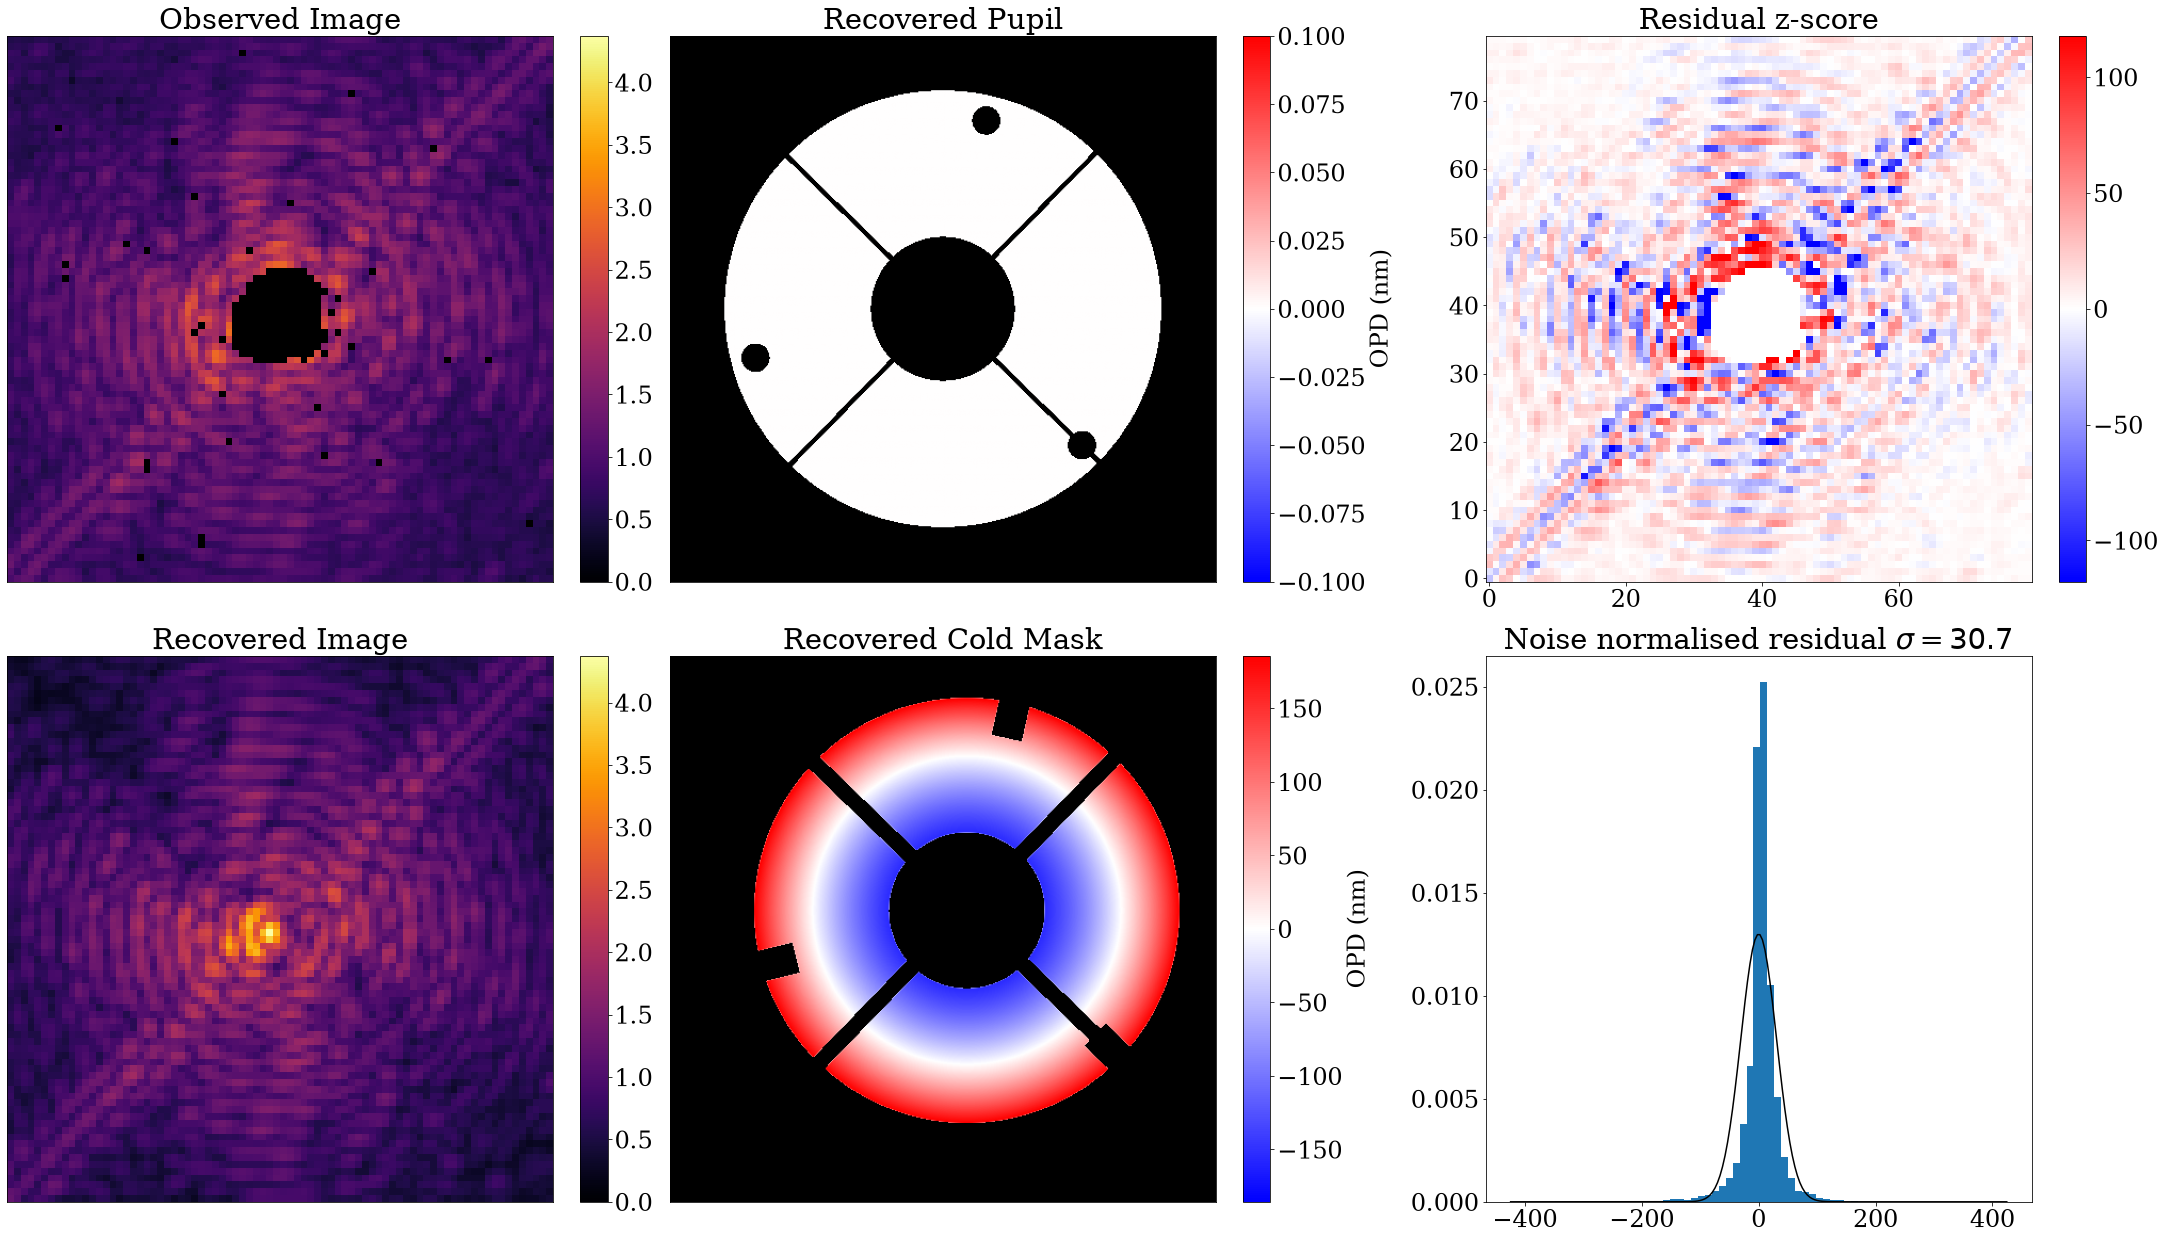

In [13]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=wf_wid)

In [14]:
g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*2, 0),

    "spectrum": sgd(g*1, 0),
    "primary_tilt": sgd(g*1., 0),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*1., 0),

    "bias": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*1, 0),
    "cold_mask_rot": sgd(g*5., 50),
    "primary_rot": sgd(g*3., 0),

    "primary_low": sgd(g*1, 0),

    "cold_mask_scale": sgd(g*1, 0),
    "cold_mask_shear": sgd(g*1, 0),

    "primary_shear": sgd(g*1, 0),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 0),
    "occulter_coeffs": sgd(g*1, 0),

    "secondary_radius": sgd(g*1., 0),
    "spider_width": sgd(g*1., 0),
    "primary_spider": sgd(g*1., 0),

    "fnumber": sgd(g*1., 0),
    "anisotropy": sgd(g*1., 0),


}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*3., 15.),
    "cold_mask_tilt": sgd(g*0.3, 0),
    "cold_mask_opd": sgd(g*0.2, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*10., 70),
    "cold_mask_rot": sgd(g*3., 85),
    "primary_rot": sgd(g*20., 85),

    "primary_low": sgd(g*0.05, 150),

    "cold_mask_scale": sgd(g*5, 100),
    "cold_mask_shear": sgd(g*10, 100),

    "primary_shear": sgd(g*5, 100),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 120),
    "occulter_coeffs": sgd(g*1, 120),

    # "outer_radius": sgd(g*1., 120),
    "secondary_radius": sgd(g*1., 120),
    "spider_width": sgd(g*1., 120),
    "primary_spider": sgd(g*1., 120),

    "fnumber": sgd(g*1., 200),
    "anisotropy": sgd(g*2., 200),
}

groups = list(things.keys())

In [15]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [16]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 600,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/600 [00:00<?, ?it/s]

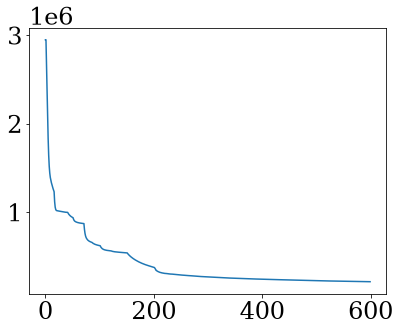

In [17]:
plt.plot(losses[:])

19
8.458510555831927


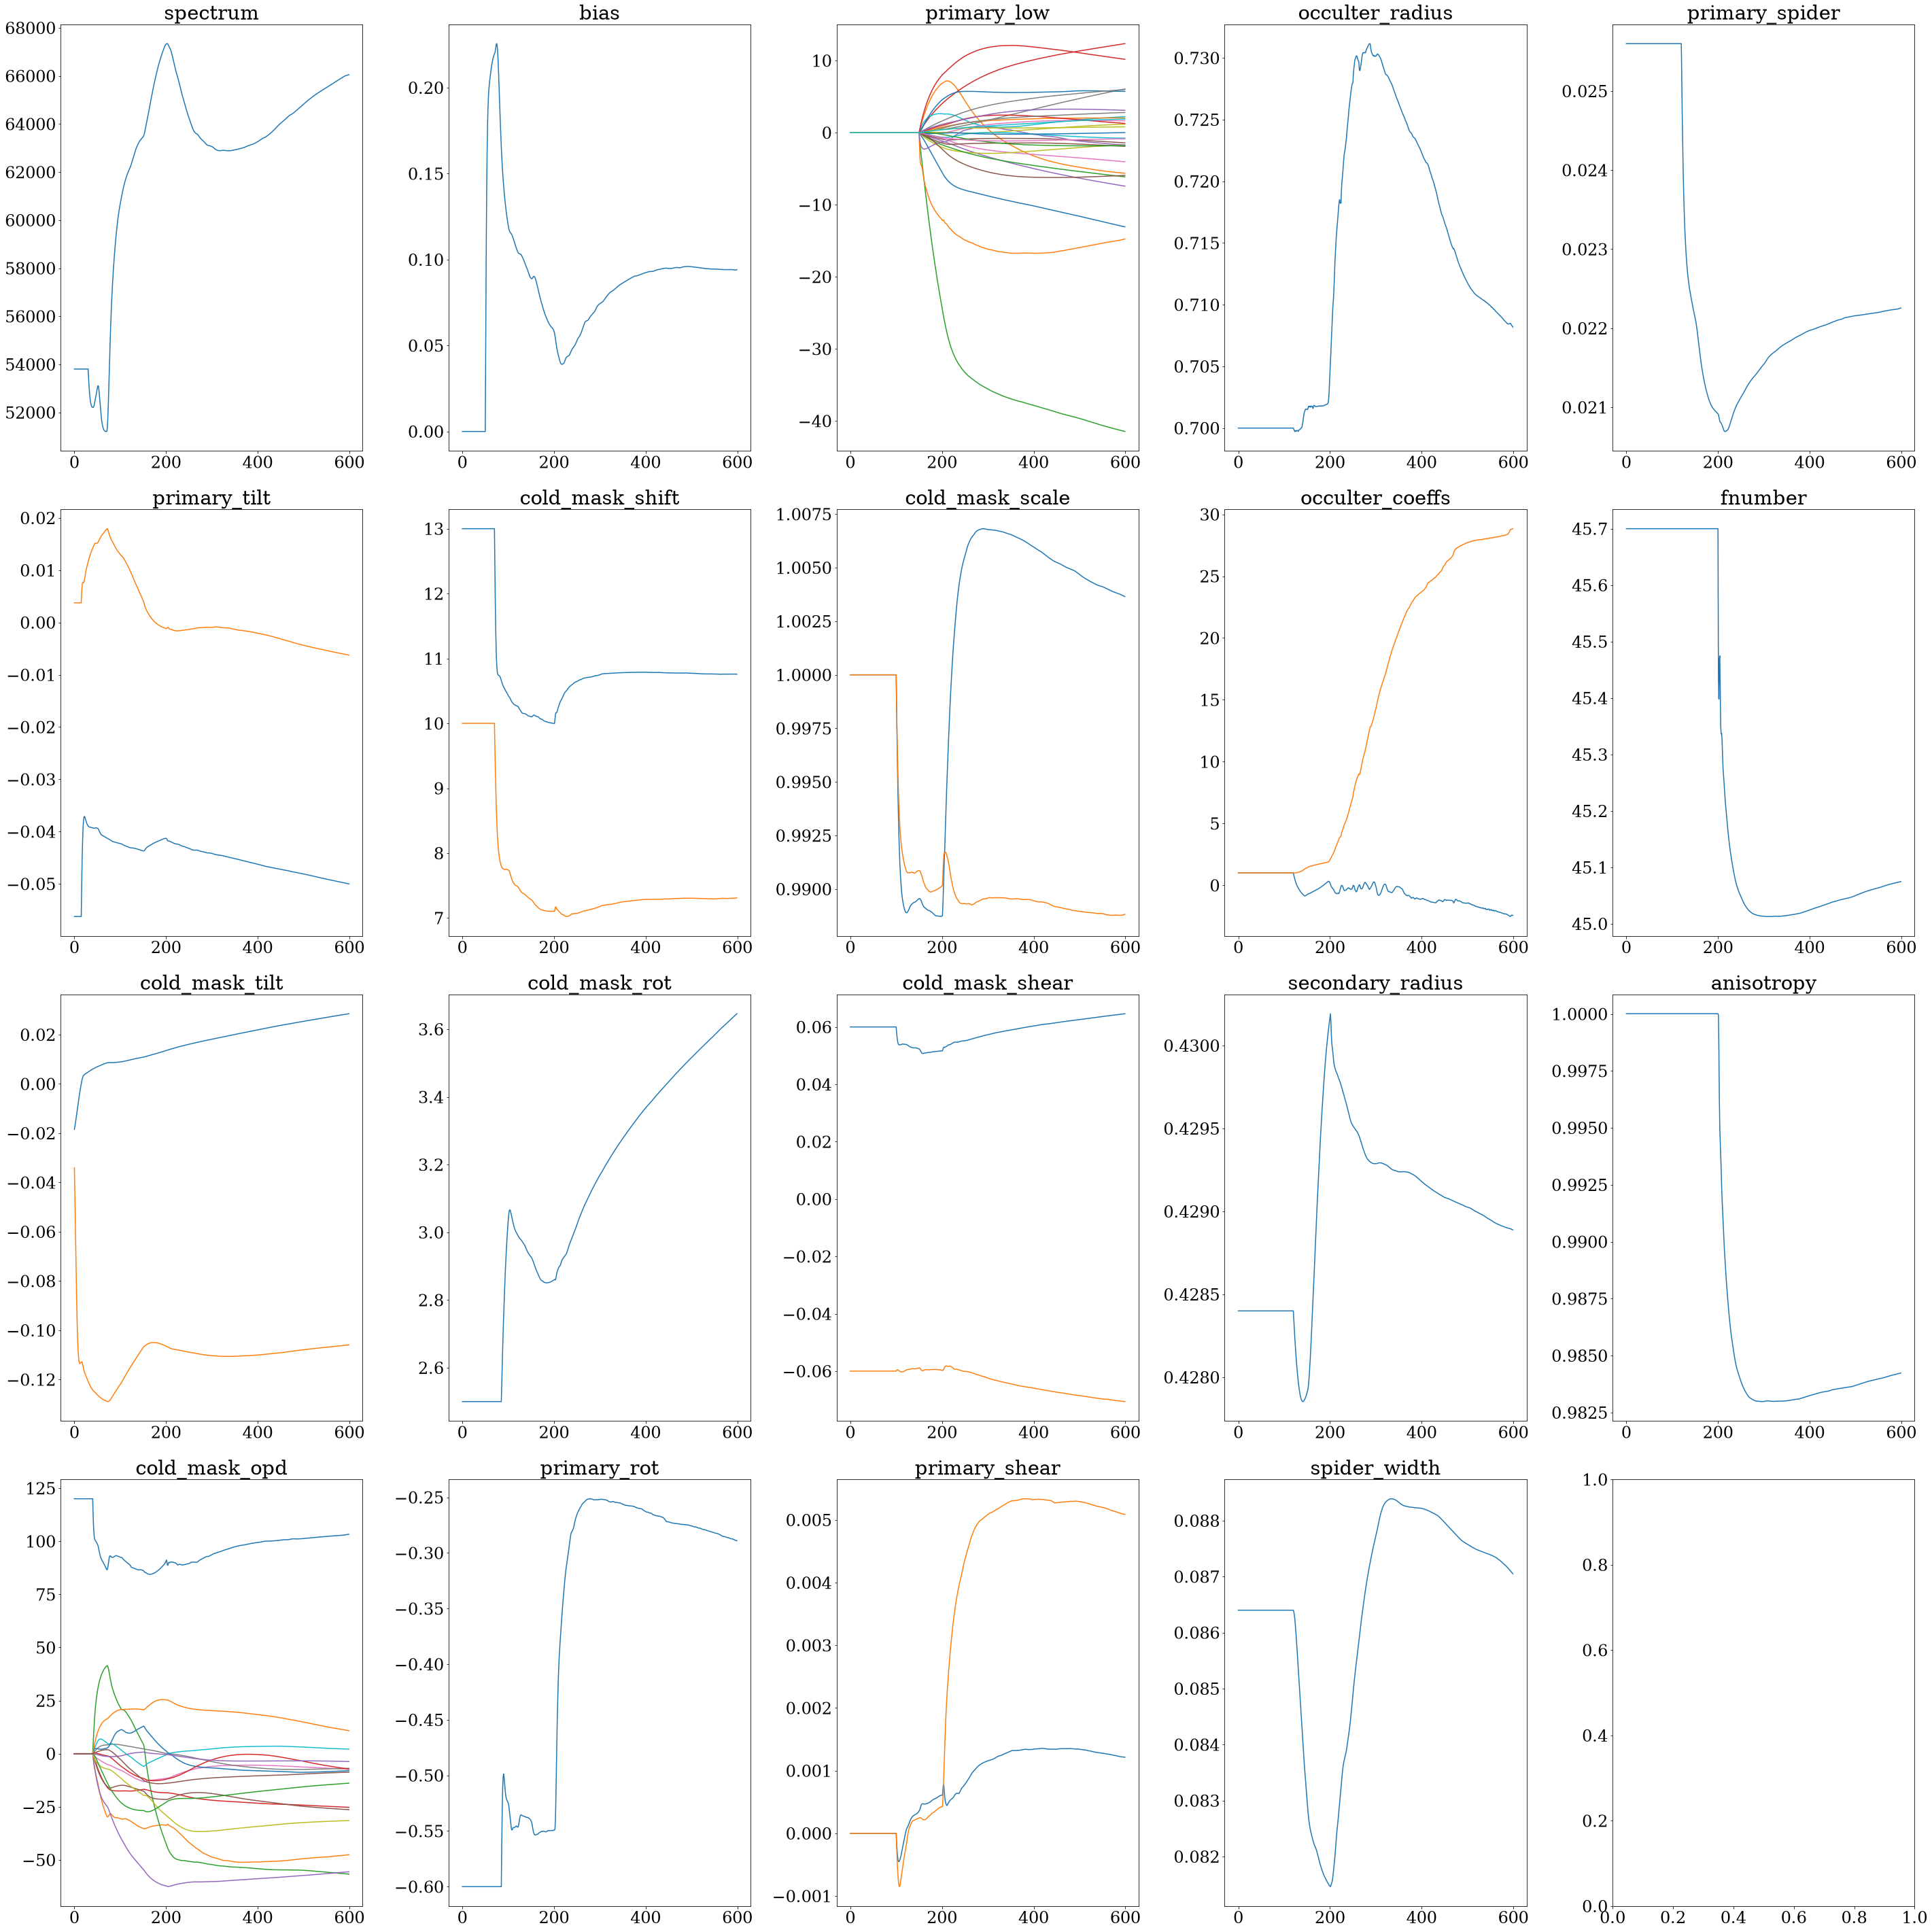

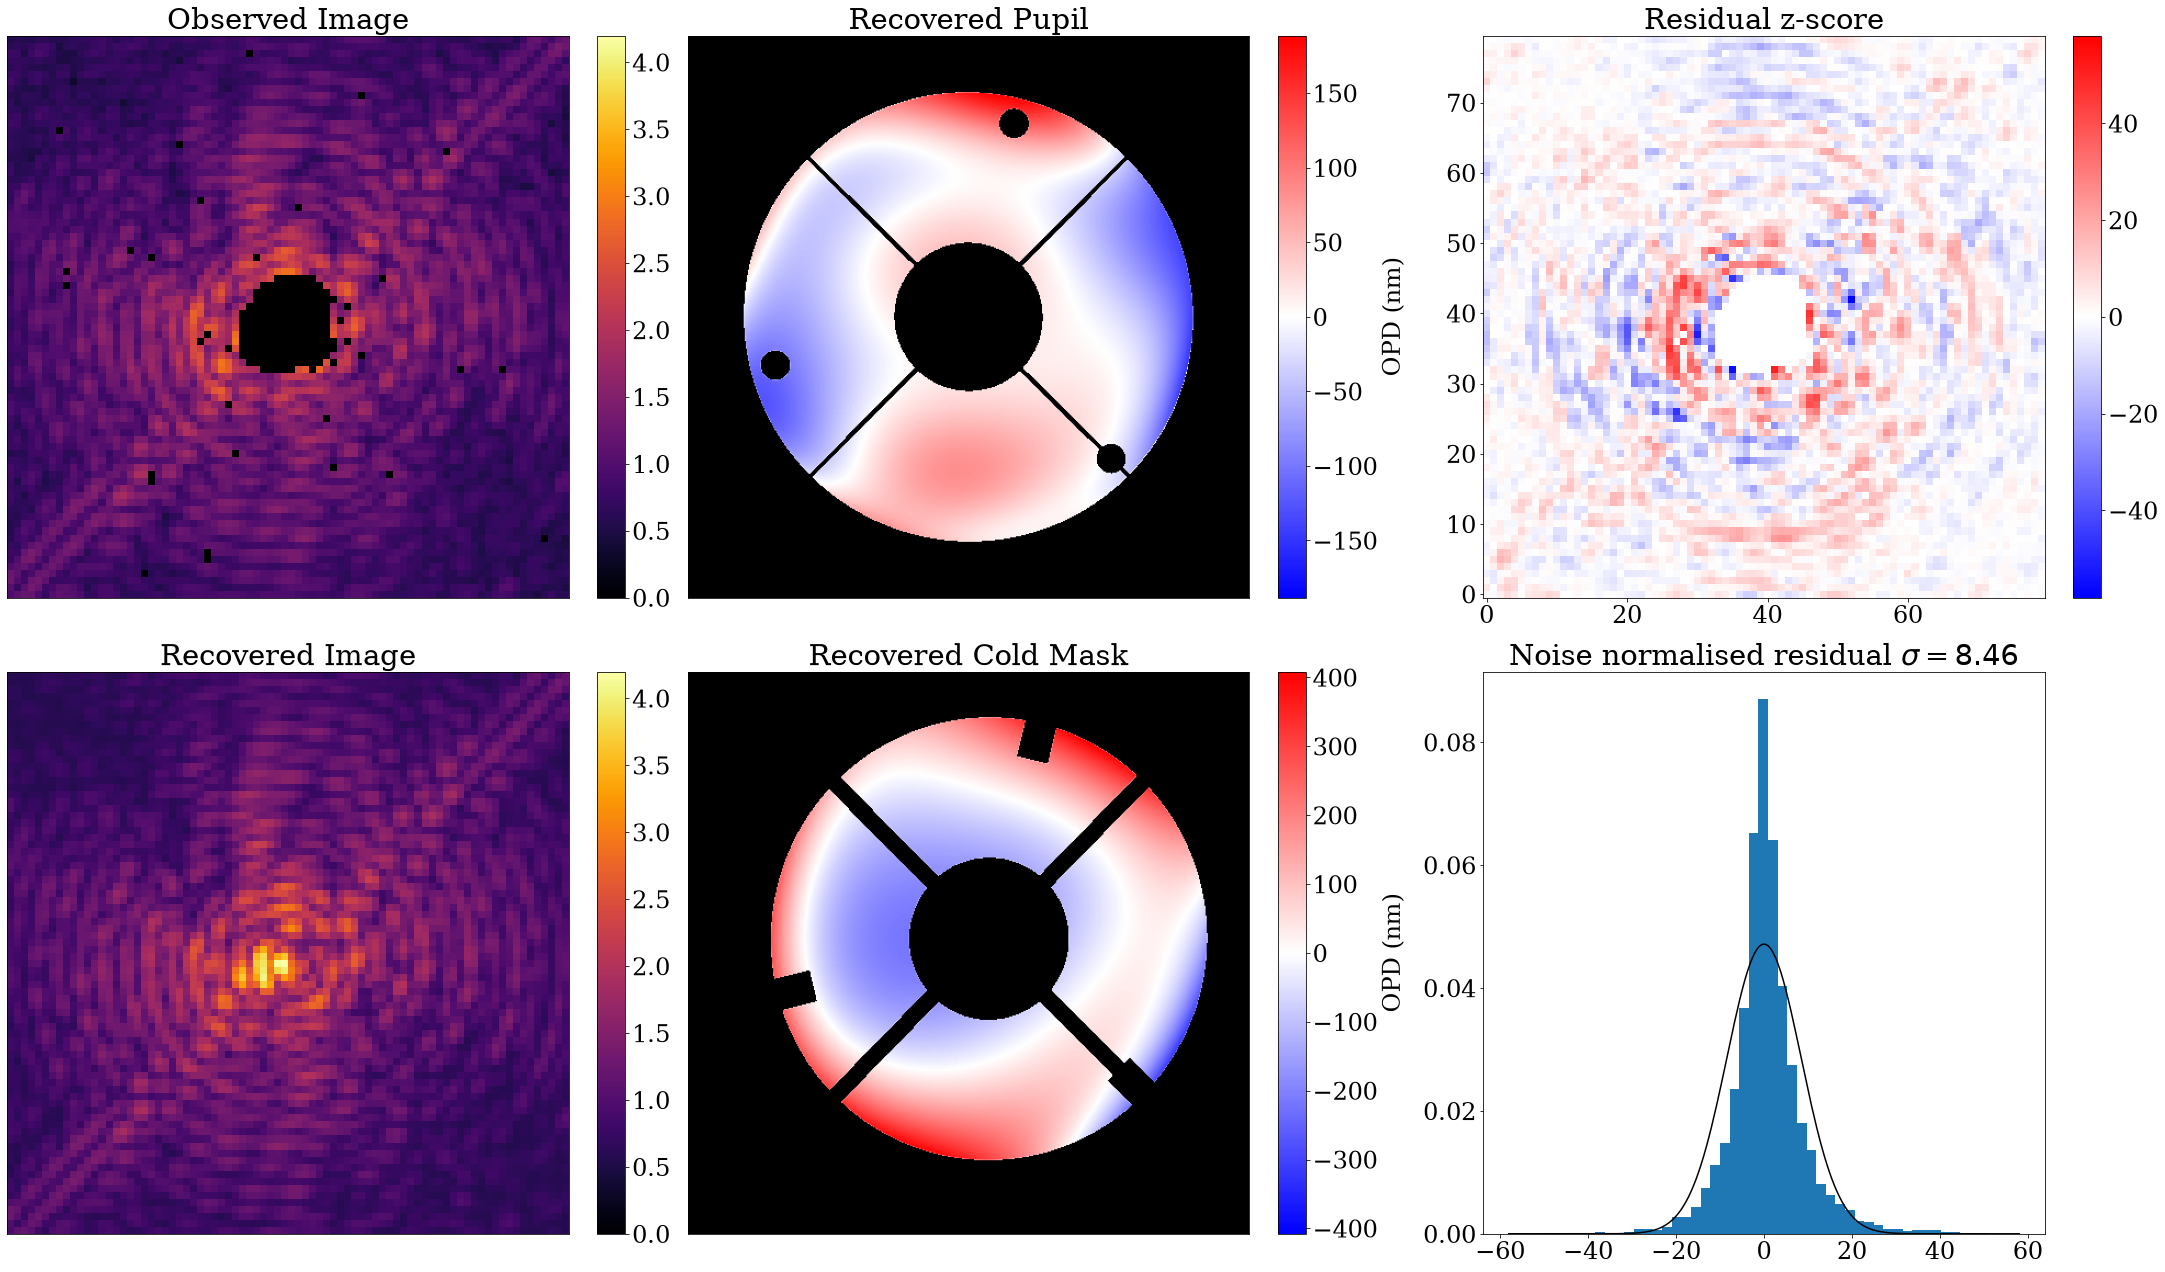

In [18]:
plot_params(params_history, list(things_start.keys()), xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=wf_wid)

In [19]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [20]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [21]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [22]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [23]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[1], ss=f64[1], normalise=False)

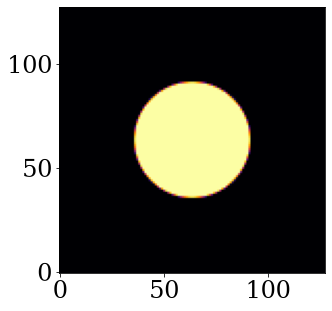

In [24]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

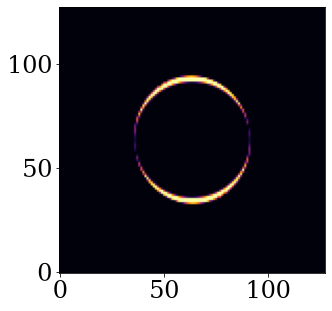

In [25]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

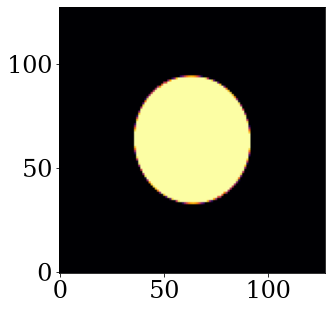

In [26]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [27]:
params_history[-1]

{'anisotropy': Array(0.98423497, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.0941038, dtype=float64)},
 'cold_mask_opd': {'global': Array([103.26820452, -47.55066377, -56.6585414 , -25.24179432,
         -55.56641126, -26.35127441,  -7.27648695,  -6.87489122,
         -31.48184727,   2.15947264,  -7.99868302,  10.83835202,
         -13.86264123,  -7.22228031,  -3.6918025 ,  -8.69348782],      dtype=float64)},
 'cold_mask_rot': {'global': Array(3.64572284, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.00365246, 0.98882137], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.06460804, -0.07062171], dtype=float64)},
 'cold_mask_shift': {'global': Array([10.75702886,  7.31161852], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.02848947, -0.10595958], dtype=float64)},
 'fnumber': Array(45.07474302, dtype=float64),
 'occulter_coeffs': Array([-2.44283451, 28.84021381], dtype=float64),
 'occulter_radius': Array(0.70819098, dtype=float64),
 'primary_low': {'n8jv51

In [28]:
# Keep the stage-1 values of parameters that stage 2 does not fit (stage 2 injects into model_single)
model_single = ModelParams(params_history[-1]).inject(model_single)
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [29]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 3000,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

  0%|          | 0/3000 [00:00<?, ?it/s]

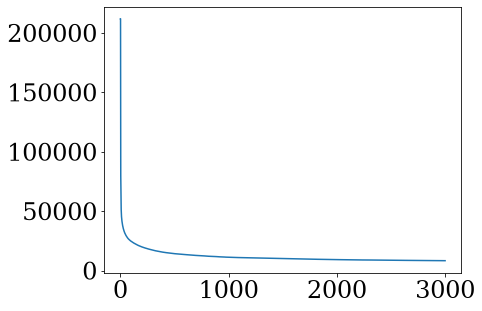

In [30]:
plt.plot(losses[:])

In [31]:
losses[-1]

Array(8260.82956498, dtype=float64)

20
2.512860173214482


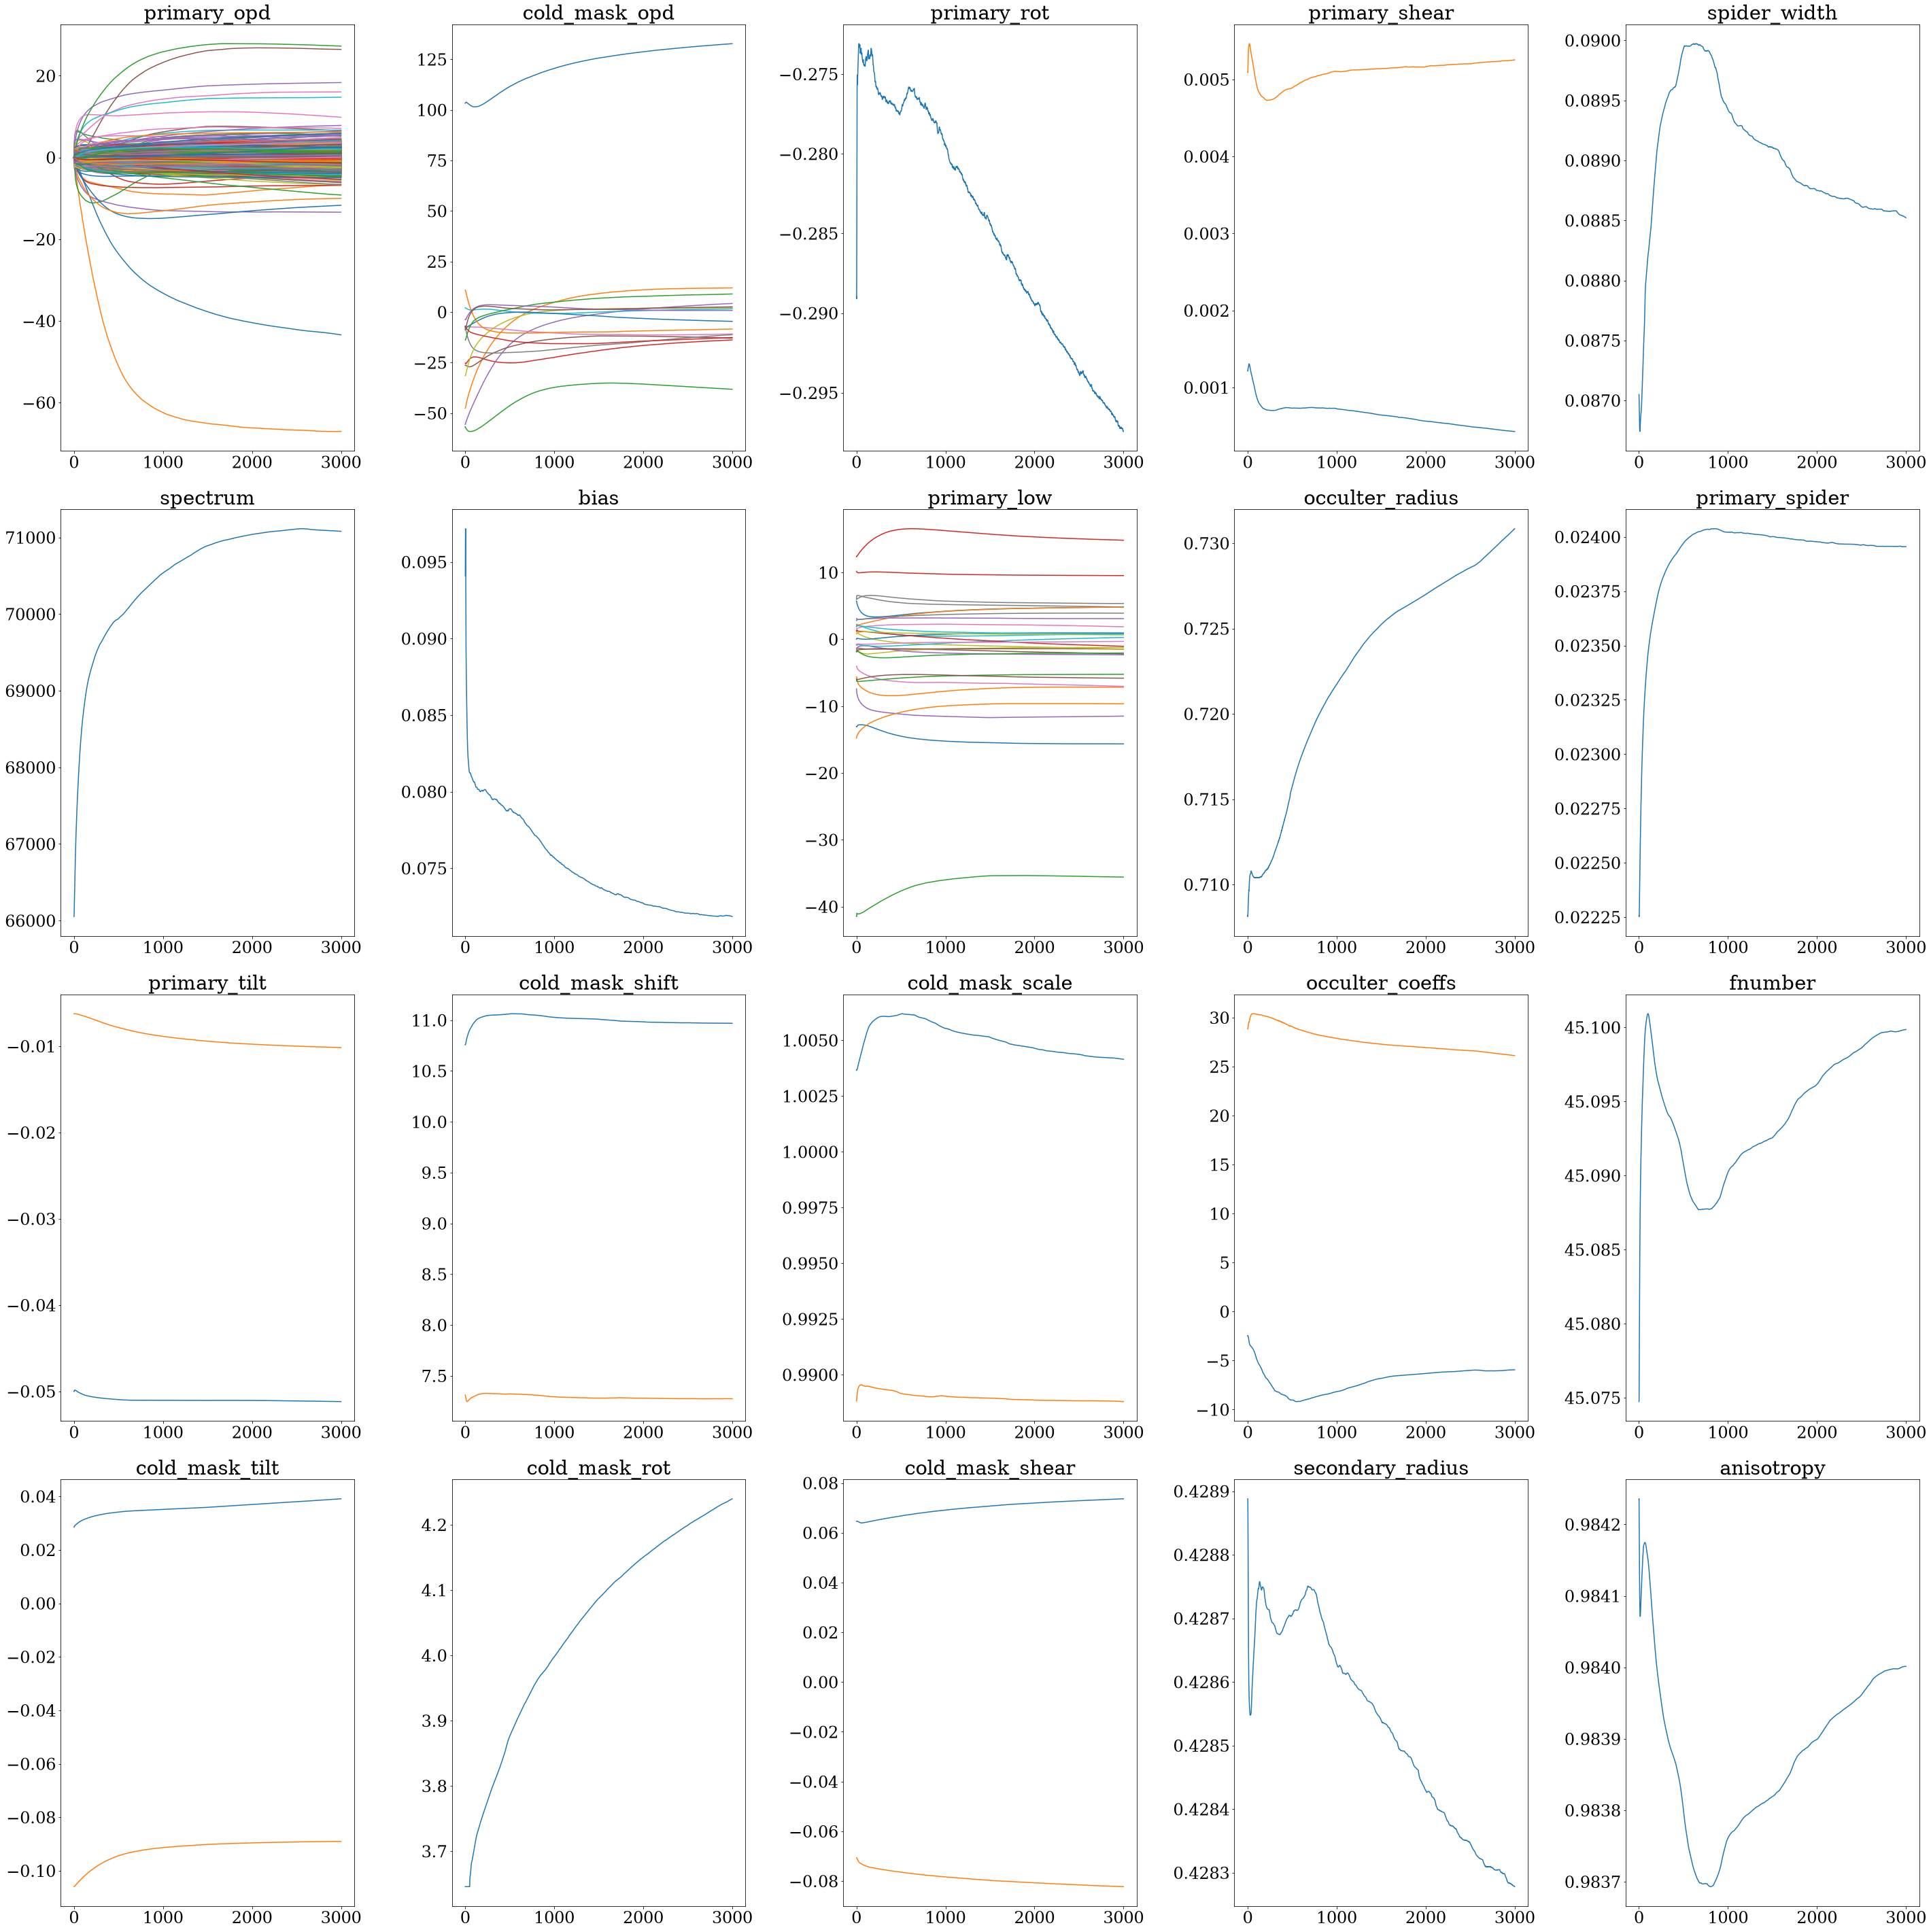

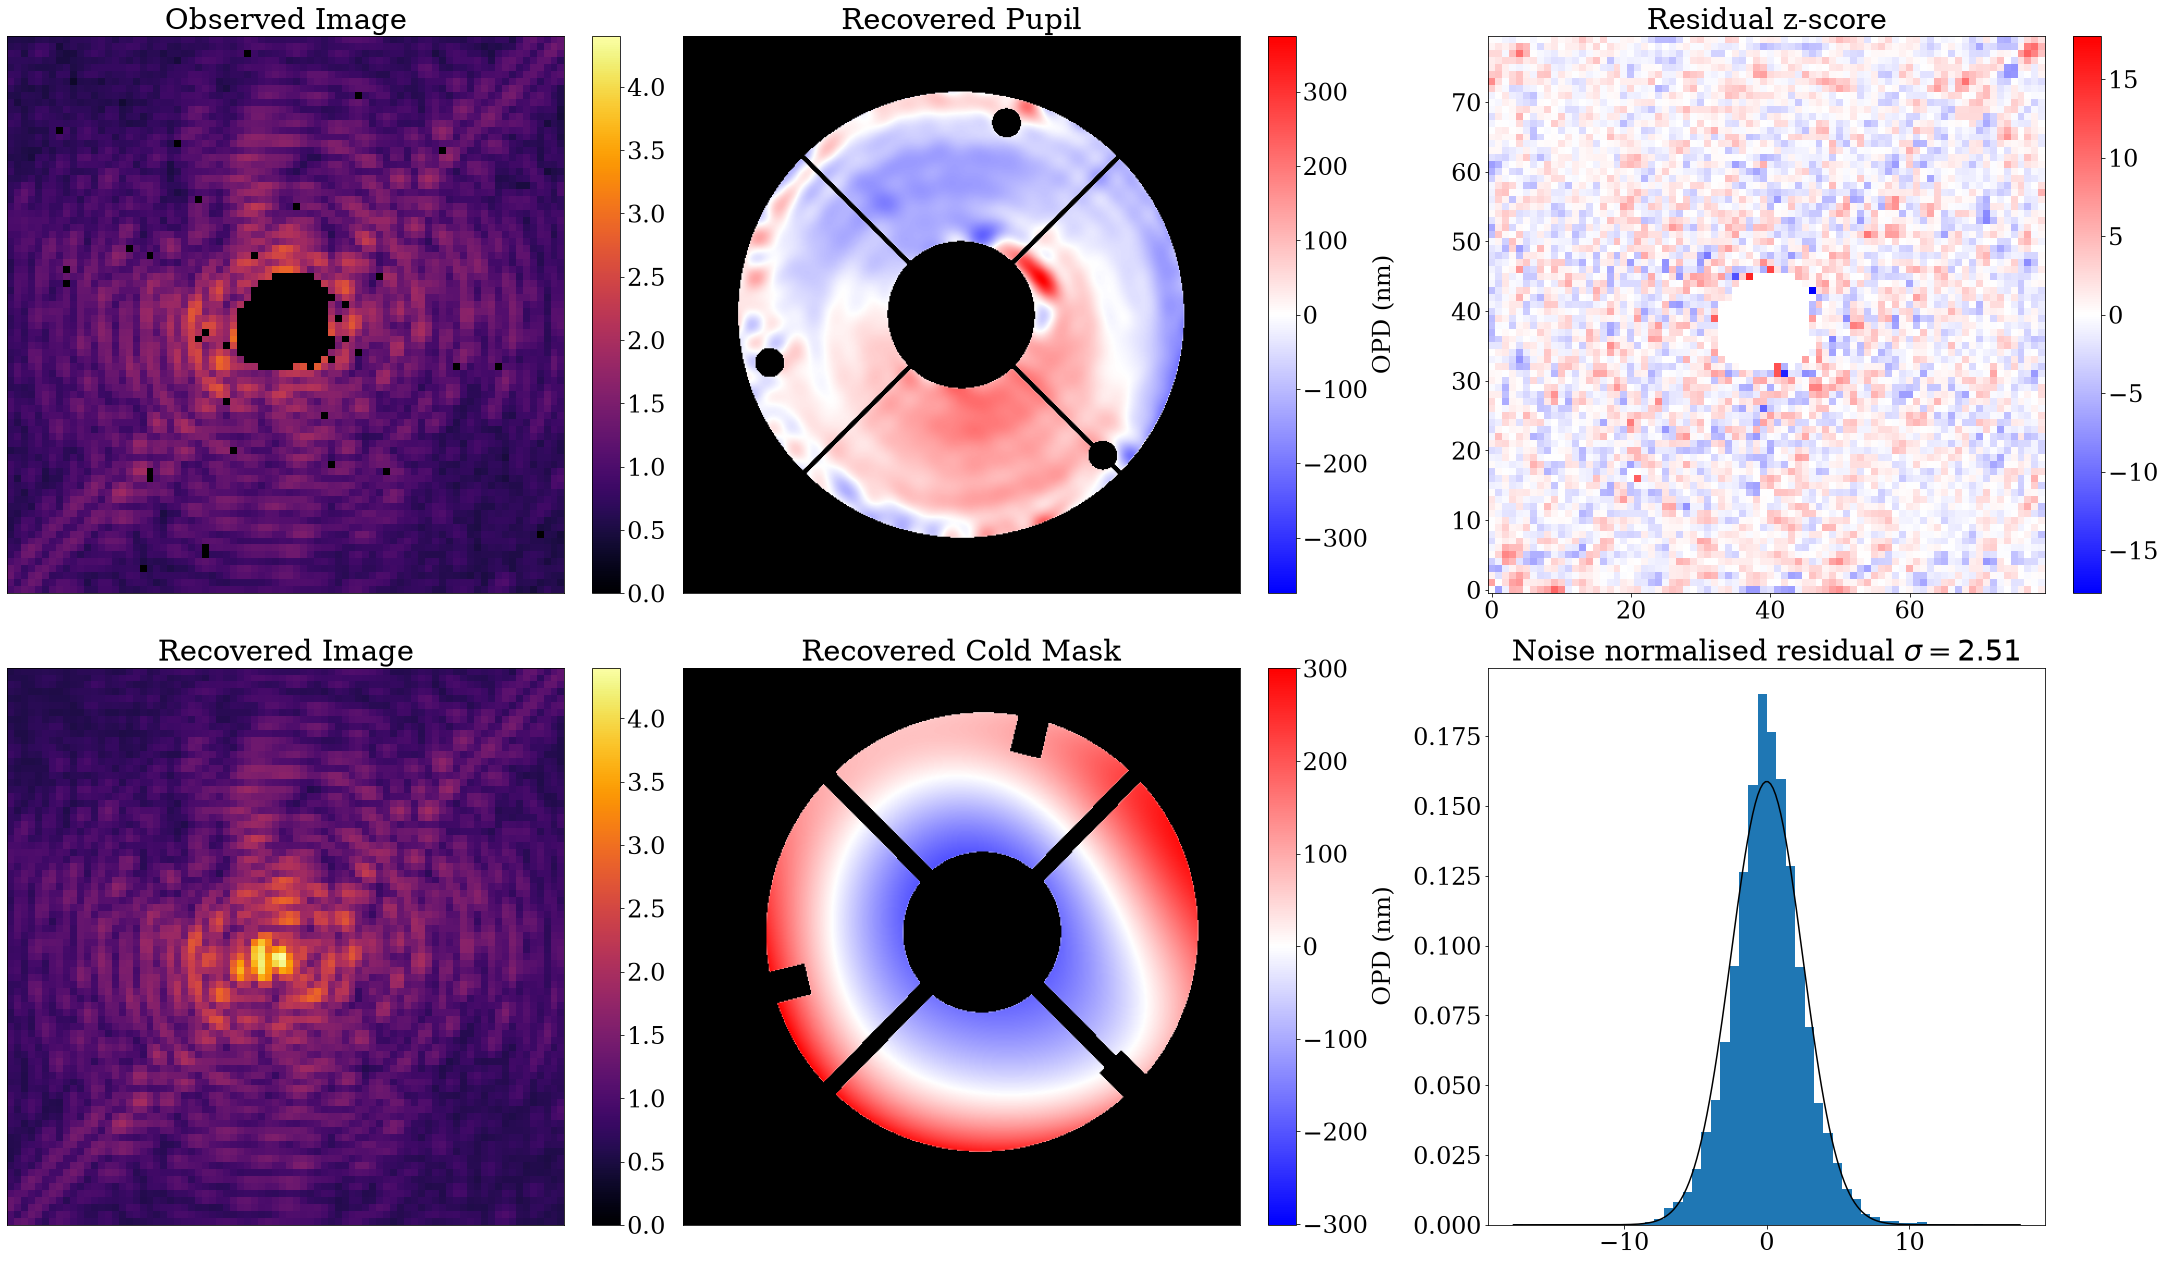

In [32]:
plot_params(params_history, groups, xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, wf_size=wf_wid, percentile=100)

([], [])

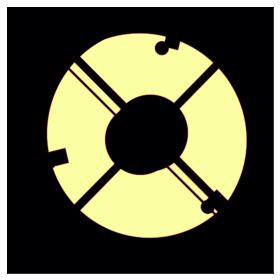

In [33]:
model = ModelParams(params_history[-1]).inject(model_single)
optics = exposures_single[0].fit.update_optics(model, exposures_single[0])
coords = dlu.pixel_coords(512, model.optics.diameter)
support = optics.primary.transmission(coords,2.4/512) * optics.cold_mask.transmission(coords,2.4/512)
plt.imshow(support)
plt.xticks([])
plt.yticks([])

([], [])

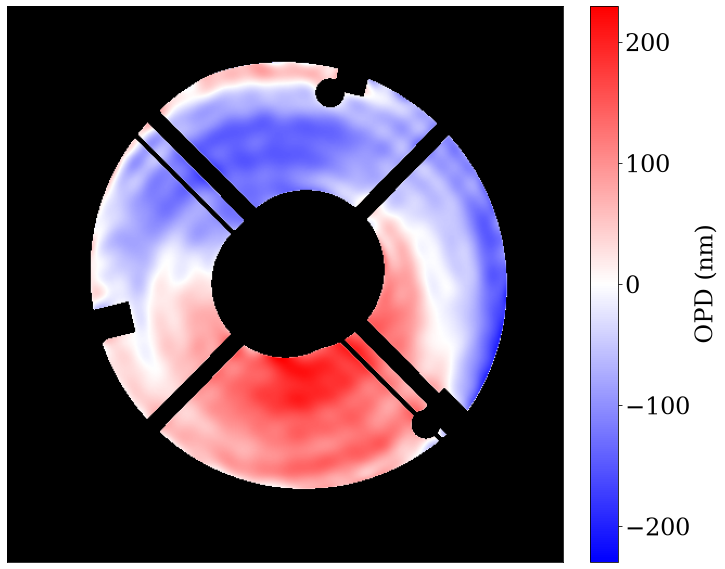

In [34]:
plt.figure(figsize=(10,10), layout="compressed")
opd = (optics.primary_opd.eval_basis() + optics.primary_low.eval_basis(coords))*1e9
support_mask = support.at[support < .5].set(np.nan)

cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)
olim = np.nanmax(np.abs(opd*support_mask))
plt.imshow(support_mask*opd,cmap=cmap,vmin=-olim, vmax=olim)
plt.colorbar().set_label("OPD (nm)")
plt.xticks([])
plt.yticks([])

In [35]:
params_history[-1]["primary_opd"]

{'global': Array([[ 0.00000000e+00, -6.54741748e+00,  5.23632727e+00, ...,
         -2.70948595e-01, -5.73195337e-01,  6.90731546e-01],
        [ 2.64487676e+01,  1.60415789e+01,  1.52626123e-02, ...,
          9.59768837e-01,  2.28506265e+00, -2.98213763e+00],
        [-4.34137897e+01, -6.70584311e+01,  2.98527127e+00, ...,
         -1.09784978e+00, -1.10106317e+00,  2.69698859e+00],
        ...,
        [ 9.75529639e-01,  1.42665570e+00, -6.52855812e-01, ...,
         -4.56836927e+00,  9.87920835e-01,  2.38273820e+00],
        [ 5.79468251e-01, -6.43558793e-01,  3.39338154e-01, ...,
         -3.07465820e+00, -2.29395116e+00,  7.13178784e-01],
        [ 3.48280799e-01, -5.70765535e-01, -7.72462934e-01, ...,
          1.62049609e+00, -1.36541229e+00, -1.77328967e+00]],      dtype=float64)}

In [143]:
exposures_single[0].fit

SinglePointFit(
  source=PointSource(
    spectrum=CombinedBasisSpectrum(
      wavelengths=f64[3],
      filt_weights=f64[3],
      basis_weights=f64[1],
      basis_vects=f64[3,1]
    ),
    position=f64[2],
    flux=f64[]
  ),
  time_series=False
)

In [ ]:


model_final = ModelParams(params_history[-1]).inject(model_single)

psf2 = exposures_single[0].fit(model_final, exposures_single[0])

params_jac = {"primary_opd":params_history[-1]["primary_opd"]}



def jac_img(exp, model1,):
    psf1 = exp.fit(model1, exp)
    psf2 = exp.fit(model_final, exp) 
    return gauss_log_likelihood(psf1, (psf2, exp.err, exp.bad))

def jac_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.asarray([jac_img(exp, mdl, psf2) for exposure in exposures]).flatten()

j = lambda params: jac_fn(ModelParams(params), exposures_single, model_final)

J, unflatten = zdx.jacobian(j, params_jac, nbatches=50, checkpoint=True)

# f = lambda params: loss_fn(ModelParams(params), exposures, model)
# F, unflatten = zdx.hessian(f, params, nbatches=nbatches, checkpoint=True)

In [242]:
J

Array([[ 0., -0., -0., ..., -0.,  0.,  0.],
       [ 0., -0., -0., ...,  0.,  0.,  0.],
       [ 0., -0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0., -0., -0., ..., -0., -0., -0.],
       [ 0., -0., -0., ..., -0., -0., -0.],
       [ 0., -0.,  0., ..., -0., -0., -0.]], dtype=float64)

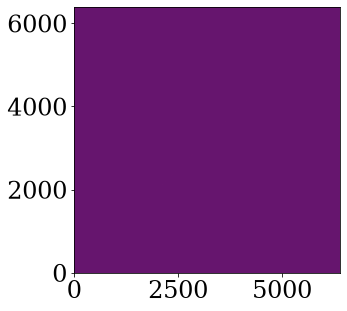

In [222]:
plt.imshow(J@J.T)

In [223]:
u, s, vh = np.linalg.svd(J, compute_uv=True)

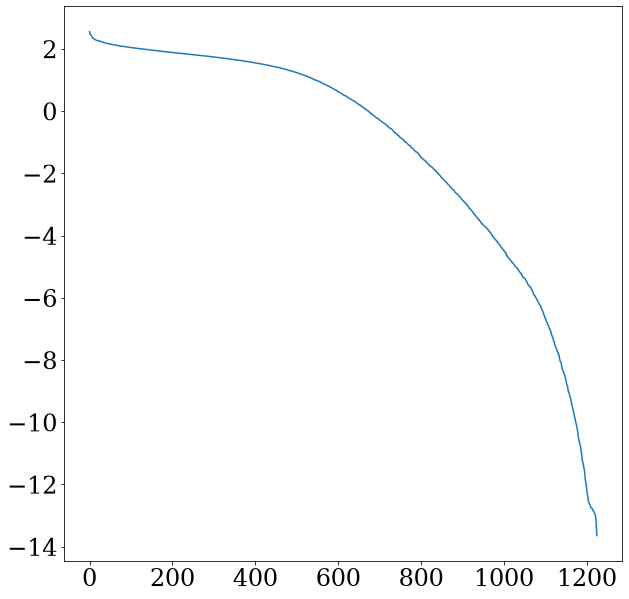

In [224]:
plt.figure(figsize=(10,10))
plt.plot(np.log10(s[:]))
# plt.plot((s[:600]))

In [225]:
vh.shape

(1225, 1225)

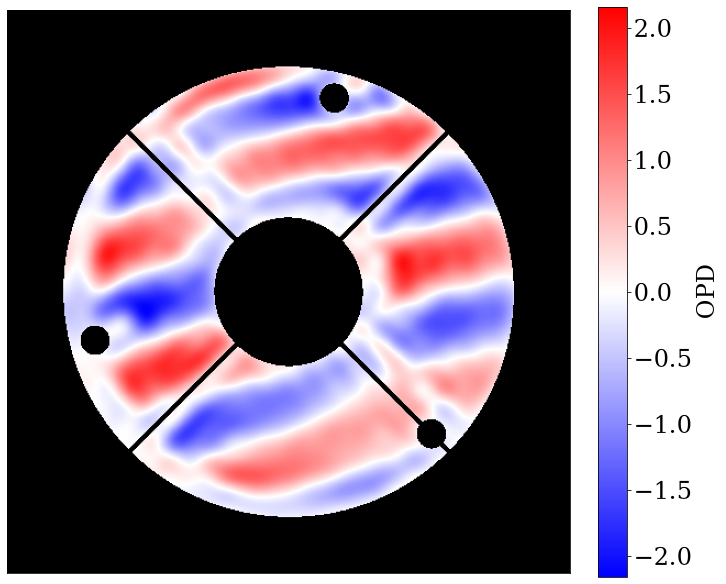

In [226]:
ap = dl.FourierBasis(512, n_modes=n_modes).set("coefficients", vh[0,:].reshape((n_modes,n_modes)))

support = optics.primary.transmission(coords,2.4/512)
support_mask = support.at[support < .5].set(np.nan)

opd = ap.eval_basis()*support_mask
cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


m = np.nanmax(np.abs(opd))
plt.figure(figsize=(10,8), layout="constrained")
plt.imshow(opd, cmap=cmap, vmin=-m, vmax=m)
plt.xticks([])
plt.yticks([])
plt.colorbar(label="OPD")
# plt.title("Breathing Mode Principal Component")

In [227]:
fourier_basis = params_history[-1]["primary_opd"]["global"]

In [237]:
N = 570
eigenbasis_coeffs = (vh[:N]@fourier_basis.flatten())

In [238]:
projected_eigenbasis = np.dot(vh[:N].T,eigenbasis_coeffs)

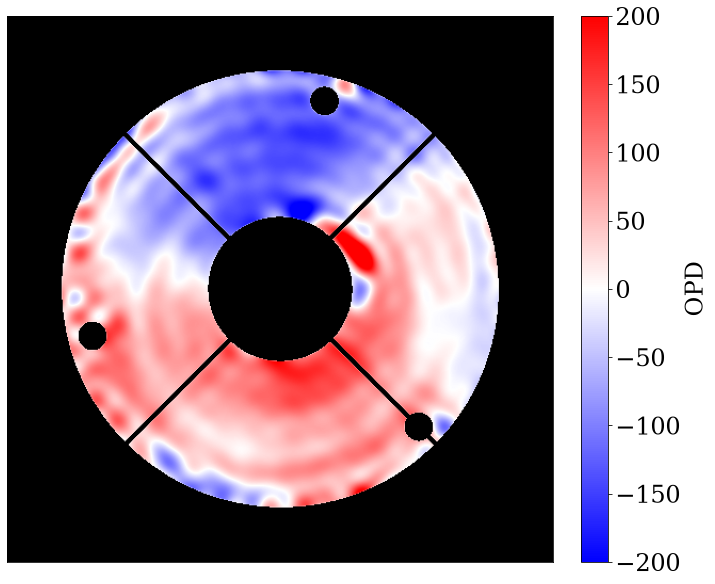

In [239]:
ap = dl.FourierBasis(512, n_modes=n_modes).set("coefficients", fourier_basis)

support = optics.primary.transmission(coords,2.4/512)
support_mask = support.at[support < .5].set(np.nan)

opd = ap.eval_basis()*support_mask
cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


m = 200#np.nanmax(np.abs(opd))
plt.figure(figsize=(10,8), layout="constrained")
plt.imshow(opd, cmap=cmap, vmin=-m, vmax=m)
plt.xticks([])
plt.yticks([])
plt.colorbar(label="OPD")
# plt.title("Breathing Mode Principal Component")

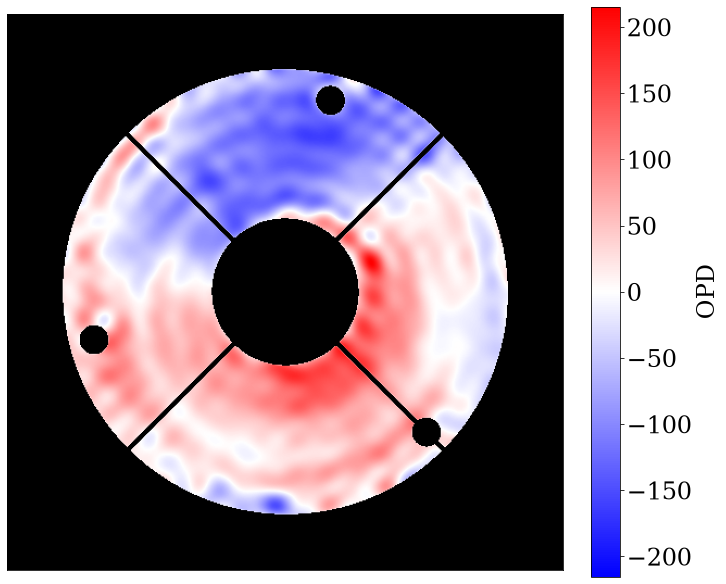

In [240]:
ap = dl.FourierBasis(512, n_modes=n_modes).set("coefficients", projected_eigenbasis.reshape((n_modes,n_modes)))

support = optics.primary.transmission(coords,2.4/512)# * optics.cold_mask.transmission(coords,2.4/512)
support_mask = support.at[support < .5].set(np.nan)

opd = ap.eval_basis()*support_mask
cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)


m = np.nanmax(np.abs(opd))
plt.figure(figsize=(10,8), layout="constrained")
plt.imshow(opd, cmap=cmap, vmin=-m, vmax=m)
plt.xticks([])
plt.yticks([])
plt.colorbar(label="OPD")
# plt.title("Breathing Mode Principal Component")